In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, AdaBoostRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
final_dataset = pd.read_csv("final_dataset.csv")
final_dataset

,match_id,Radiant_1,Radiant_2,Radiant_3,Radiant_4,Radiant_5,Dire_1,Dire_2,Dire_3,Dire_4,Dire_5,radiant_win
0,0,86,51,83,11,67,106,102,46,7,73,True
1,1,7,82,71,39,21,73,22,5,67,106,False
2,2,51,109,9,41,27,38,7,10,12,85,False
3,3,50,44,32,26,39,78,19,31,40,47,False
4,4,8,39,55,87,69,101,100,22,67,21,True
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49995,73,86,21,20,14,32,7,109,35,112,True
49996,49996,93,74,100,32,85,36,1,112,60,71,True
49997,49997,100,68,75,39,44,28,102,21,9,23,True
49998,49998,56,50,2,72,30,46,7,29,44,3,True


## Data encoding

In [5]:
categorical_columns = ["radiant_win"]

X_cat = final_dataset[categorical_columns]



encoder = OneHotEncoder(drop='first').fit(X_cat)
cols = encoder.get_feature_names_out(input_features=X_cat.columns)
X_cat_encode = pd.DataFrame(encoder.transform(X_cat).toarray(),columns=cols)
X_cat_encode.head()

,radiant_win_True
0,1.0
1,0.0
2,0.0
3,0.0
4,1.0


In [6]:
final_dataset_encode = pd.concat([final_dataset, X_cat_encode], axis=1)
final_dataset_encode = final_dataset_encode.drop(columns=["radiant_win"])
final_dataset_encode

,match_id,Radiant_1,Radiant_2,Radiant_3,Radiant_4,Radiant_5,Dire_1,Dire_2,Dire_3,Dire_4,Dire_5,radiant_win_True
0,0,86,51,83,11,67,106,102,46,7,73,1.0
1,1,7,82,71,39,21,73,22,5,67,106,0.0
2,2,51,109,9,41,27,38,7,10,12,85,0.0
3,3,50,44,32,26,39,78,19,31,40,47,0.0
4,4,8,39,55,87,69,101,100,22,67,21,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49995,73,86,21,20,14,32,7,109,35,112,1.0
49996,49996,93,74,100,32,85,36,1,112,60,71,1.0
49997,49997,100,68,75,39,44,28,102,21,9,23,1.0
49998,49998,56,50,2,72,30,46,7,29,44,3,1.0


In [29]:
#final_dataset_encode.to_csv("final_dataset_encode.csv", index=False)

## Correlation Matrix

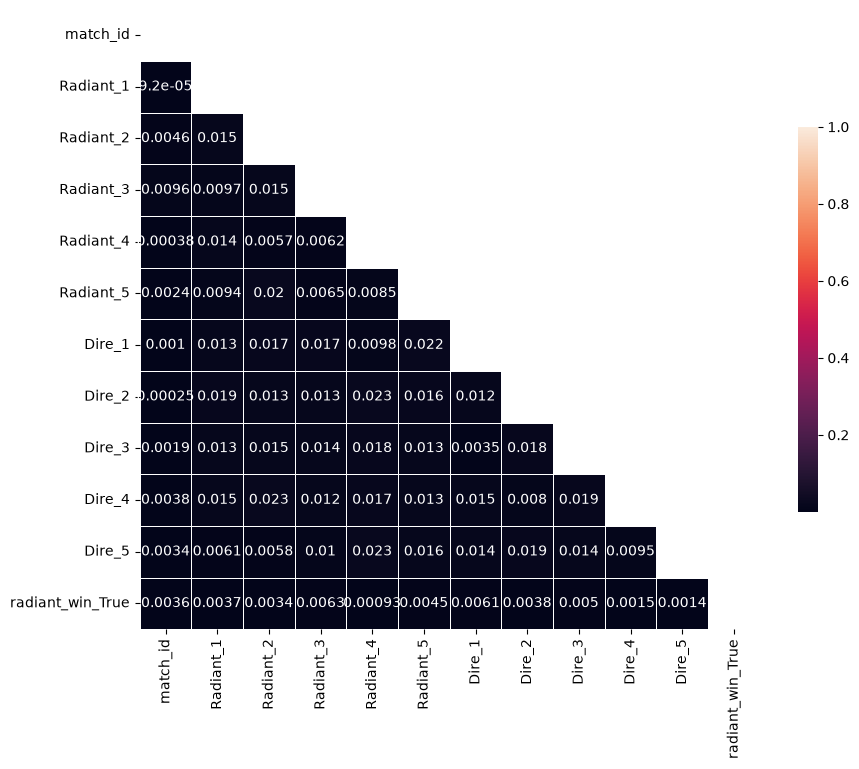

In [7]:
corr=np.abs(final_dataset_encode.corr())

#Set up mask for triangle representation
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratioqq
sns.heatmap(corr, mask=mask,  vmax=1,square=True, linewidths=.5, cbar_kws={"shrink": .5},annot = corr)

plt.show()

## Feature and Target

In [13]:
features = final_dataset_encode.drop(columns = ["radiant_win_True"])
target = final_dataset_encode["radiant_win_True"]

## Model Training

In [14]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

In [15]:
normalizer = MinMaxScaler()

normalizer.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](122,)","[49999., 112., 112.,..., 1., 1., 1.]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](122,)","[ 0., 0., 0.,...,-1.,-1.,-1.]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](122,)","[49999., 112., 112.,..., 2., 2., 2.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](122,)","['match_id','Radiant_1','Radiant_2',...,'hero_49','hero_66','hero_0']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](122,)","[0. ,0. ,0. ,...,0.5,0.5,0.5]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,122
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,40000


In [16]:
X_train_norm = normalizer.transform(X_train)
X_test_norm = normalizer.transform(X_test)

X_train_norm = pd.DataFrame(X_train_norm, columns = X_train.columns)
X_test_norm = pd.DataFrame(X_test_norm, columns = X_test.columns)

## Random forest classifier

In [19]:
rf_class = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_class.fit(X_train, y_train)

y_pred = rf_class.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)) 
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.523
Confusion Matrix:
[[2193 2576]
 [2194 3037]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.46      0.48      4769
         1.0       0.54      0.58      0.56      5231

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.52     10000
weighted avg       0.52      0.52      0.52     10000



## Transforming data for better results

In [8]:
radiant_cols = ["Radiant_1","Radiant_2","Radiant_3","Radiant_4","Radiant_5"]
dire_cols = ["Dire_1","Dire_2","Dire_3","Dire_4","Dire_5"]

hero_ids = pd.unique(final_dataset_encode[radiant_cols + dire_cols].values.ravel())

# Create one column for every hero
for hero in hero_ids:

    final_dataset_encode[f"hero_{hero}"] = 0

# Hero on Radiant = 1
for col in radiant_cols:
    for index in final_dataset_encode.index:
        hero = final_dataset_encode.loc[index, col]
        final_dataset_encode.loc[index, f"hero_{hero}"] = 1

# Hero on Dire = -1
for col in dire_cols:
    for index in final_dataset_encode.index:
        hero = final_dataset_encode.loc[index, col]
        final_dataset_encode.loc[index, f"hero_{hero}"] = -1

X = final_dataset_encode.drop(columns=["match_id","radiant_win_True","Radiant_1", "Radiant_2","Radiant_3","Radiant_4","Radiant_5","Dire_1","Dire_2","Dire_3","Dire_4",
    "Dire_5"])

y = final_dataset_encode["radiant_win_True"]

print(X.shape)
X.head()

(50000, 111)


,hero_86,hero_51,hero_83,hero_11,hero_67,hero_106,hero_102,hero_46,hero_7,hero_73,...,hero_37,hero_92,hero_80,hero_88,hero_17,hero_15,hero_79,hero_49,hero_66,hero_0
0,1,1,1,1,1,-1,-1,-1,-1,-1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,-1,-1,0,0,1,-1,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,-1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X.to_csv("X.csv", index=False)

In [11]:
y.to_csv("y.csv", index=False)

## Training the model with the new transformend data

## Random Forest

In [18]:
X_train_trans, X_test_trans, y_train_trans, y_test_trans = train_test_split(X, y, test_size = 0.20, random_state=0)

In [15]:
rf_class = RandomForestClassifier(n_estimators=100,random_state=42)

rf_class.fit(X_train_trans, y_train_trans)

y_pred_trans = rf_class.predict(X_test_trans)

print("Accuracy:", accuracy_score(y_test_trans, y_pred_trans)) 
print("Confusion Matrix:")
print(confusion_matrix(y_test_trans, y_pred_trans))

print("Classification Report:")
print(classification_report(y_test_trans, y_pred_trans))

Accuracy: 0.5829
Confusion Matrix:
[[2538 2231]
 [1940 3291]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.57      0.53      0.55      4769
         1.0       0.60      0.63      0.61      5231

    accuracy                           0.58     10000
   macro avg       0.58      0.58      0.58     10000
weighted avg       0.58      0.58      0.58     10000



## LogisticRegression

In [19]:
from sklearn.linear_model import LogisticRegression

l_reg = LogisticRegression(max_iter=1000)

l_reg.fit(X_train_trans, y_train_trans)

y_pred_log = l_reg.predict(X_test_trans)

print("Accuracy:", accuracy_score(y_test_trans, y_pred_log))
print(confusion_matrix(y_test_trans, y_pred_log))
print(classification_report(y_test_trans, y_pred_log))

Accuracy: 0.5982
[[2605 2164]
 [1854 3377]]
              precision    recall  f1-score   support

         0.0       0.58      0.55      0.56      4769
         1.0       0.61      0.65      0.63      5231

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.60      0.60      0.60     10000



## Gradient Boosting

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_trans, y_train_trans)

y_pred_gb = gb.predict(X_test_trans)

print("Accuracy:", accuracy_score(y_test_trans, y_pred_gb))
print(confusion_matrix(y_test_trans, y_pred_gb))
print(classification_report(y_test_trans, y_pred_gb))

Accuracy: 0.5826
[[2193 2576]
 [1598 3633]]
              precision    recall  f1-score   support

         0.0       0.58      0.46      0.51      4769
         1.0       0.59      0.69      0.64      5231

    accuracy                           0.58     10000
   macro avg       0.58      0.58      0.57     10000
weighted avg       0.58      0.58      0.58     10000



## knn classification

In [41]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_trans, y_train_trans)

y_pred_knn = knn.predict(X_test_trans)

print("Accuracy:", accuracy_score(y_test_trans, y_pred_knn))
print(confusion_matrix(y_test_trans, y_pred_knn))
print(classification_report(y_test_trans, y_pred_knn))

Accuracy: 0.531
[[2935 1834]
 [2856 2375]]
              precision    recall  f1-score   support

         0.0       0.51      0.62      0.56      4769
         1.0       0.56      0.45      0.50      5231

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.53     10000
weighted avg       0.54      0.53      0.53     10000



## Hyperparameter Tuning

In [20]:
from sklearn.model_selection import GridSearchCV

grid = {"C": [0.01, 0.1, 1, 10, 100]}

l_reg = LogisticRegression(max_iter=1000)

model = GridSearchCV(estimator=l_reg,param_grid=grid,cv=5,scoring="accuracy")

model.fit(X_train_trans, y_train_trans)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with 

In [21]:
model.best_params_
best_model = model.best_estimator_

In [22]:
pred_tune = best_model.predict(X_test_trans)

print("Accuracy:", accuracy_score(y_test_trans, pred_tune))

#print("Confusion Matrix:")
print(confusion_matrix(y_test_trans, pred_tune))

#print("Classification Report:")
print(classification_report(y_test_trans, pred_tune))

Accuracy: 0.6001
[[2594 2175]
 [1824 3407]]
              precision    recall  f1-score   support

         0.0       0.59      0.54      0.56      4769
         1.0       0.61      0.65      0.63      5231

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.60      0.60      0.60     10000



In [23]:
import joblib

joblib.dump(best_model, "dota_model.pkl")
joblib.dump(normalizer, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']